# 07 — OPT Coherence & Entropy Analysis

Analyses the pre-scored stories in `results_with_500/with_scores/` for the **Qwen2.5-1.5B-Instruct** model.

**Plots:**
1. **Generation-model entropy over token position** — per-token entropy from Qwen (`chunk_entropies`), dynamic vs fixed schedules.
2. **OPT-1.3B entropy over token position** — evaluator model's per-token entropy (`opt_token_entropies`) after the float16 softmax fix.
3. **OPT Coherence** — per-story `coherence_opt` score (bar + box + violin).
4. **Entropy per chunk** — mean entropy per chunk, shows how it tracks the temperature schedule.

In [16]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), ".."))

import json
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib
matplotlib.rcParams["figure.dpi"] = 130
matplotlib.rcParams["font.size"] = 10

In [17]:
# ── Paths & schedule definitions ───────────────────────────────────────────────
RESULTS_DIR = os.path.join("..", "results_with_500", "with_scores")
MODEL_PREFIX = "Qwen_Qwen2.5-1.5B-Instruct"

DYNAMIC_SCHEDULES = ["decreasing", "increasing", "peak", "valley"]
FIXED_SCHEDULES   = ["fixed_0.5", "fixed_0.7", "fixed_1.0", "fixed_1.2"]
ALL_SCHEDULES     = DYNAMIC_SCHEDULES + FIXED_SCHEDULES

# Prettier labels
LABELS = {
    "decreasing": "Decreasing\n[1.3→0.5]",
    "increasing": "Increasing\n[0.5→1.3]",
    "peak":       "Peak\n[0.5,1.3,0.5]",
    "valley":     "Valley\n[1.3,0.5,1.3]",
    "fixed_0.5":  "Fixed 0.5",
    "fixed_0.7":  "Fixed 0.7",
    "fixed_1.0":  "Fixed 1.0",
    "fixed_1.2":  "Fixed 1.2",
}

DYNAMIC_COLORS = plt.cm.tab10.colors[:4]
FIXED_COLORS   = plt.cm.Set2.colors[:4]

In [18]:
# ── Load scored stories ────────────────────────────────────────────────────────
def load_scored(sched_name):
    path = os.path.join(RESULTS_DIR, f"{MODEL_PREFIX}_{sched_name}", "stories_opt_scored.jsonl")
    if not os.path.exists(path):
        return None
    with open(path) as f:
        return [json.loads(l) for l in f]

data = {}
for sched in ALL_SCHEDULES:
    stories = load_scored(sched)
    if stories:
        data[sched] = stories
        mean_coh = np.mean([s["coherence_opt"] for s in stories])
        temps = stories[0]["temperatures"]
        print(f"{sched:15s}: {len(stories):3d} stories | coherence_opt mean={mean_coh:.4f} | temps={temps}")
    else:
        print(f"{sched:15s}: NOT FOUND")

decreasing     :  50 stories | coherence_opt mean=-4.3660 | temps=[1.3, 1.1, 0.9, 0.7, 0.5]
increasing     :  50 stories | coherence_opt mean=-4.3584 | temps=[0.5, 0.7, 0.9, 1.1, 1.3]
peak           :  50 stories | coherence_opt mean=-4.3070 | temps=[0.5, 0.9, 1.3, 0.9, 0.5]
valley         :  50 stories | coherence_opt mean=-4.4627 | temps=[1.3, 0.9, 0.5, 0.9, 1.3]
fixed_0.5      :  50 stories | coherence_opt mean=-4.0826 | temps=[0.5, 0.5, 0.5, 0.5, 0.5]
fixed_0.7      :  50 stories | coherence_opt mean=-4.1507 | temps=[0.7, 0.7, 0.7, 0.7, 0.7]
fixed_1.0      :  50 stories | coherence_opt mean=-4.3883 | temps=[1.0, 1.0, 1.0, 1.0, 1.0]
fixed_1.2      :  29 stories | coherence_opt mean=-4.5303 | temps=[1.2, 1.2, 1.2, 1.2, 1.2]


In [19]:
# ── Helper: flatten chunk_entropies → full token sequence ─────────────────────
def flatten_chunk_entropies(stories, replace_neg_zero=True):
    """
    Returns array of shape (n_stories, total_tokens) with NaN padding.
    Replaces -0.0 (padding sentinels) with NaN.
    """
    seqs = []
    for s in stories:
        flat = []
        for chunk in s["chunk_entropies"]:
            for v in chunk:
                flat.append(np.nan if (replace_neg_zero and v == -0.0 and math.copysign(1, v) < 0) else v)
        seqs.append(flat)
    max_len = max(len(s) for s in seqs)
    arr = np.full((len(seqs), max_len), np.nan)
    for i, seq in enumerate(seqs):
        arr[i, :len(seq)] = seq
    return arr

def get_chunk_boundaries(stories):
    """Return token index where each chunk starts (based on first story)."""
    boundaries = [0]
    for chunk in stories[0]["chunk_entropies"]:
        boundaries.append(boundaries[-1] + len(chunk))
    return boundaries

def smooth(arr, w=15):
    if w <= 1:
        return arr
    kernel = np.ones(w) / w
    return np.convolve(arr, kernel, mode="same")

entropy_arrays = {sched: flatten_chunk_entropies(stories) for sched, stories in data.items()}
for sched, arr in entropy_arrays.items():
    print(f"{sched:15s}: shape={arr.shape}, mean_entropy={np.nanmean(arr):.3f}")

decreasing     : shape=(50, 500), mean_entropy=1.694
increasing     : shape=(50, 500), mean_entropy=1.685
peak           : shape=(50, 500), mean_entropy=1.615
valley         : shape=(50, 500), mean_entropy=1.754
fixed_0.5      : shape=(50, 500), mean_entropy=1.073
fixed_0.7      : shape=(50, 500), mean_entropy=1.383
fixed_1.0      : shape=(50, 500), mean_entropy=1.783
fixed_1.2      : shape=(29, 500), mean_entropy=2.008


## Plot 1 — Entropy over token position
Mean ± std across stories. Vertical dashed lines mark chunk boundaries. Smoothed with a 15-token window.

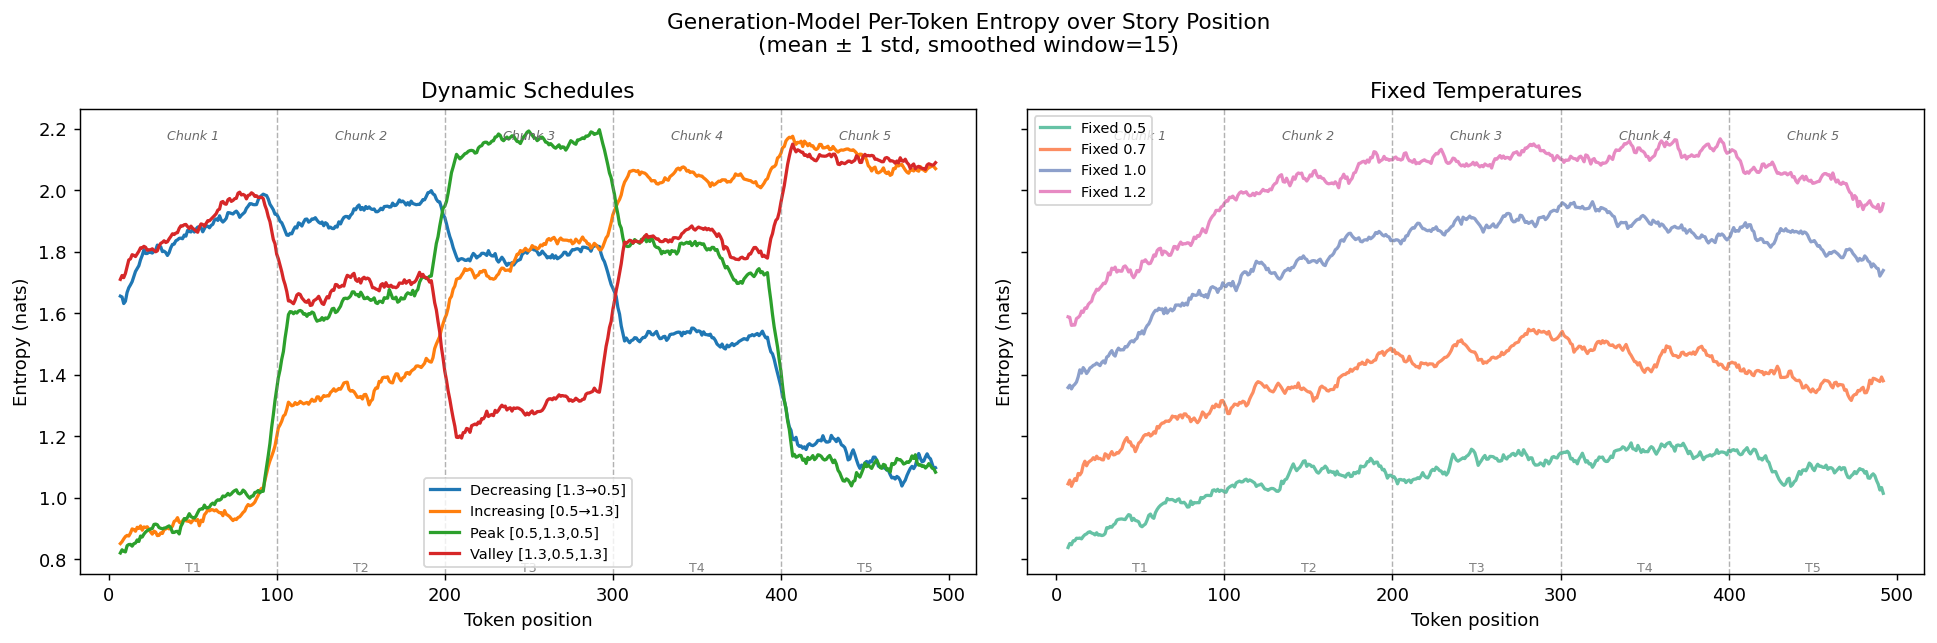

In [20]:
SMOOTH_W = 15
first_sched = list(data.keys())[0]
chunk_bounds = get_chunk_boundaries(data[first_sched])

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
fig.suptitle("Generation-Model Per-Token Entropy over Story Position\n(mean ± 1 std, smoothed window=15)", fontsize=12)

def plot_entropy_panel(ax, scheds, colors, title):
    for i, (sched, color) in enumerate(zip(scheds, colors)):
        if sched not in entropy_arrays:
            continue
        arr = entropy_arrays[sched]
        mean = np.nanmean(arr, axis=0)
        std  = np.nanstd(arr,  axis=0)
        xs   = np.arange(len(mean))
        ms   = smooth(mean, SMOOTH_W)
        ss   = smooth(std,  SMOOTH_W)
        # trim edges affected by convolution
        pad = SMOOTH_W // 2
        xs2, ms2, ss2 = xs[pad:-pad], ms[pad:-pad], ss[pad:-pad]
        label = LABELS[sched].replace("\n", " ")
        temps = data[sched][0]["temperatures"]
        ax.plot(xs2, ms2, label=f"{label}", color=color, linewidth=1.8)
        # ax.fill_between(xs2, ms2 - ss2, ms2 + ss2, alpha=0.15, color=color)
    # chunk boundaries
    for b in chunk_bounds[1:-1]:
        ax.axvline(b, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)
    # temperature annotations above x-axis
    temps_ex = data[scheds[0] if scheds[0] in data else scheds[-1]][0]["temperatures"]
    for j, (start, end) in enumerate(zip(chunk_bounds[:-1], chunk_bounds[1:])):
        mid = (start + end) / 2
        ax.text(mid, ax.get_ylim()[0] if ax.get_ylim()[0] > -1 else 0,
                f"T{j+1}", ha="center", va="bottom", fontsize=7, color="grey")
    ax.set_xlabel("Token position")
    ax.set_ylabel("Entropy (nats)")
    ax.set_title(title)
    ax.legend(fontsize=8)

plot_entropy_panel(axes[0], DYNAMIC_SCHEDULES, DYNAMIC_COLORS, "Dynamic Schedules")
plot_entropy_panel(axes[1], FIXED_SCHEDULES,   FIXED_COLORS,   "Fixed Temperatures")

# Add chunk label on right panel
for ax in axes:
    for j, (start, end) in enumerate(zip(chunk_bounds[:-1], chunk_bounds[1:])):
        mid = (start + end) / 2
        ax.text(mid, ax.get_ylim()[1] * 0.97, f"Chunk {j+1}",
                ha="center", va="top", fontsize=7, color="dimgrey", style="italic")

plt.tight_layout()
os.makedirs(os.path.join("..", "results_with_500", "plots"), exist_ok=True)
plt.savefig(os.path.join("..", "results_with_500", "plots", "entropy_over_time.png"), dpi=150)
plt.show()

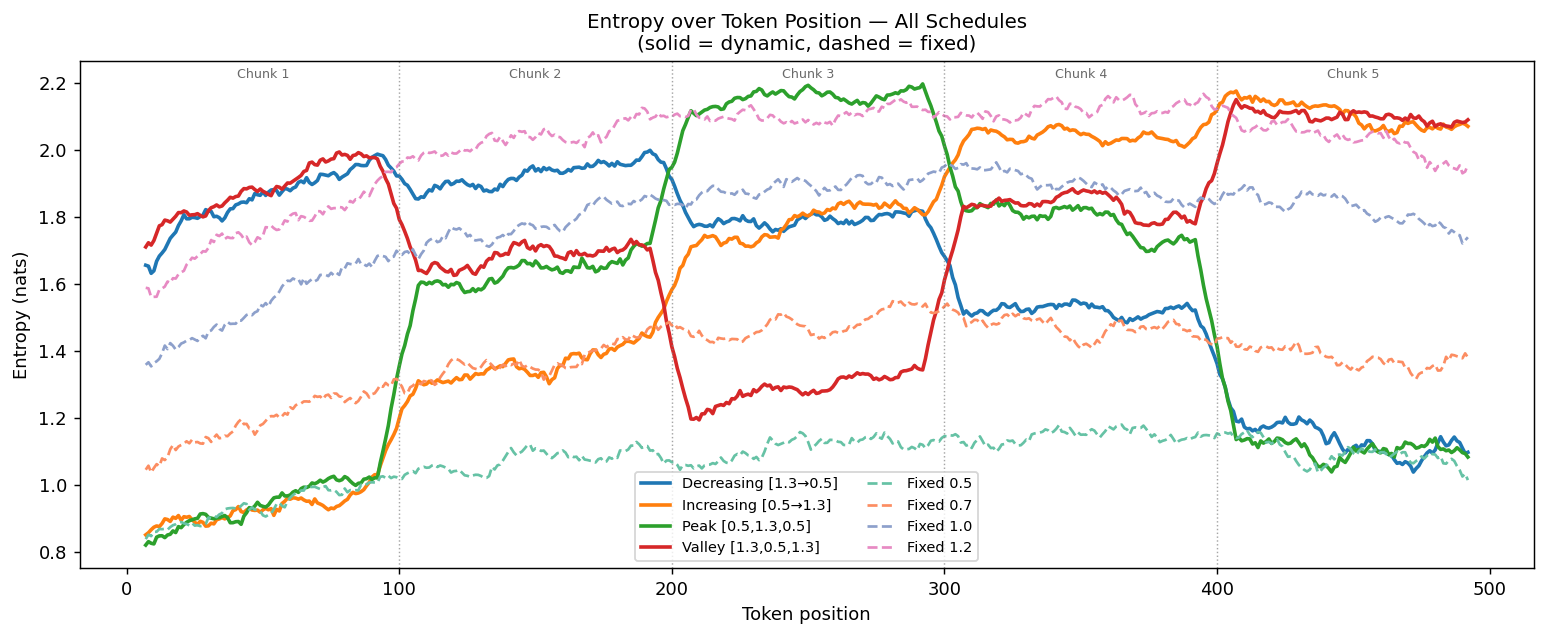

In [21]:
# ── Overlay: all schedules in one plot, dynamic vs fixed distinguished by linestyle ──
fig, ax = plt.subplots(figsize=(12, 5))
ax.set_title("Entropy over Token Position — All Schedules\n(solid = dynamic, dashed = fixed)", fontsize=11)

for i, sched in enumerate(DYNAMIC_SCHEDULES):
    if sched not in entropy_arrays:
        continue
    arr  = entropy_arrays[sched]
    mean = np.nanmean(arr, axis=0)
    xs   = np.arange(len(mean))
    ms   = smooth(mean, SMOOTH_W)
    pad  = SMOOTH_W // 2
    ax.plot(xs[pad:-pad], ms[pad:-pad],
            label=LABELS[sched].replace("\n", " "),
            color=DYNAMIC_COLORS[i], linewidth=2.0, linestyle="-")

for i, sched in enumerate(FIXED_SCHEDULES):
    if sched not in entropy_arrays:
        continue
    arr  = entropy_arrays[sched]
    mean = np.nanmean(arr, axis=0)
    xs   = np.arange(len(mean))
    ms   = smooth(mean, SMOOTH_W)
    pad  = SMOOTH_W // 2
    ax.plot(xs[pad:-pad], ms[pad:-pad],
            label=LABELS[sched],
            color=FIXED_COLORS[i], linewidth=1.5, linestyle="--")

for b in chunk_bounds[1:-1]:
    ax.axvline(b, color="grey", linestyle=":", linewidth=0.8, alpha=0.7)
for j, (start, end) in enumerate(zip(chunk_bounds[:-1], chunk_bounds[1:])):
    ax.text((start + end) / 2, ax.get_ylim()[1] * 0.99,
            f"Chunk {j+1}", ha="center", va="top", fontsize=7, color="dimgrey")

ax.set_xlabel("Token position")
ax.set_ylabel("Entropy (nats)")
ax.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join("..", "results_with_500", "plots", "entropy_over_time_overlay.png"), dpi=150)
plt.show()

## Plot 1b — OPT Per-Token Entropy over Story Position
OPT-1.3B's own per-token entropy (`opt_token_entropies`) — the evaluator model's uncertainty
about each story token, conditioned on the prompt. Re-run notebook 06 scoring after the float16
softmax fix to populate this field.

In [22]:
# ── Collect opt_token_entropies into (n_stories, T) arrays ──────────────────
def collect_opt_entropy(stories):
    seqs = [s.get('opt_token_entropies', []) for s in stories]
    max_len = max(len(s) for s in seqs) if seqs else 0
    arr = np.full((len(seqs), max_len), np.nan)
    for i, seq in enumerate(seqs):
        arr[i, :len(seq)] = seq
    return arr

opt_entropy_arrays = {sched: collect_opt_entropy(stories) for sched, stories in data.items()}

for sched, arr in opt_entropy_arrays.items():
    valid_frac = np.sum(~np.isnan(arr)) / arr.size
    print(f"{sched:15s}: shape={arr.shape}, "
          f"mean={np.nanmean(arr):.3f}, "
          f"valid_frac={valid_frac:.2%}")
    if valid_frac < 0.01:
        print(f"  WARNING: nearly all NaN — re-run scoring with the fixed metrics.py")

decreasing     : shape=(50, 554), mean=3.608, valid_frac=89.43%
increasing     : shape=(50, 555), mean=3.521, valid_frac=88.61%
peak           : shape=(50, 537), mean=3.522, valid_frac=91.28%
valley         : shape=(50, 528), mean=3.604, valid_frac=91.73%
fixed_0.5      : shape=(50, 524), mean=3.414, valid_frac=92.65%
fixed_0.7      : shape=(50, 534), mean=3.506, valid_frac=91.52%
fixed_1.0      : shape=(50, 581), mean=3.573, valid_frac=84.93%
fixed_1.2      : shape=(29, 540), mean=3.734, valid_frac=89.43%


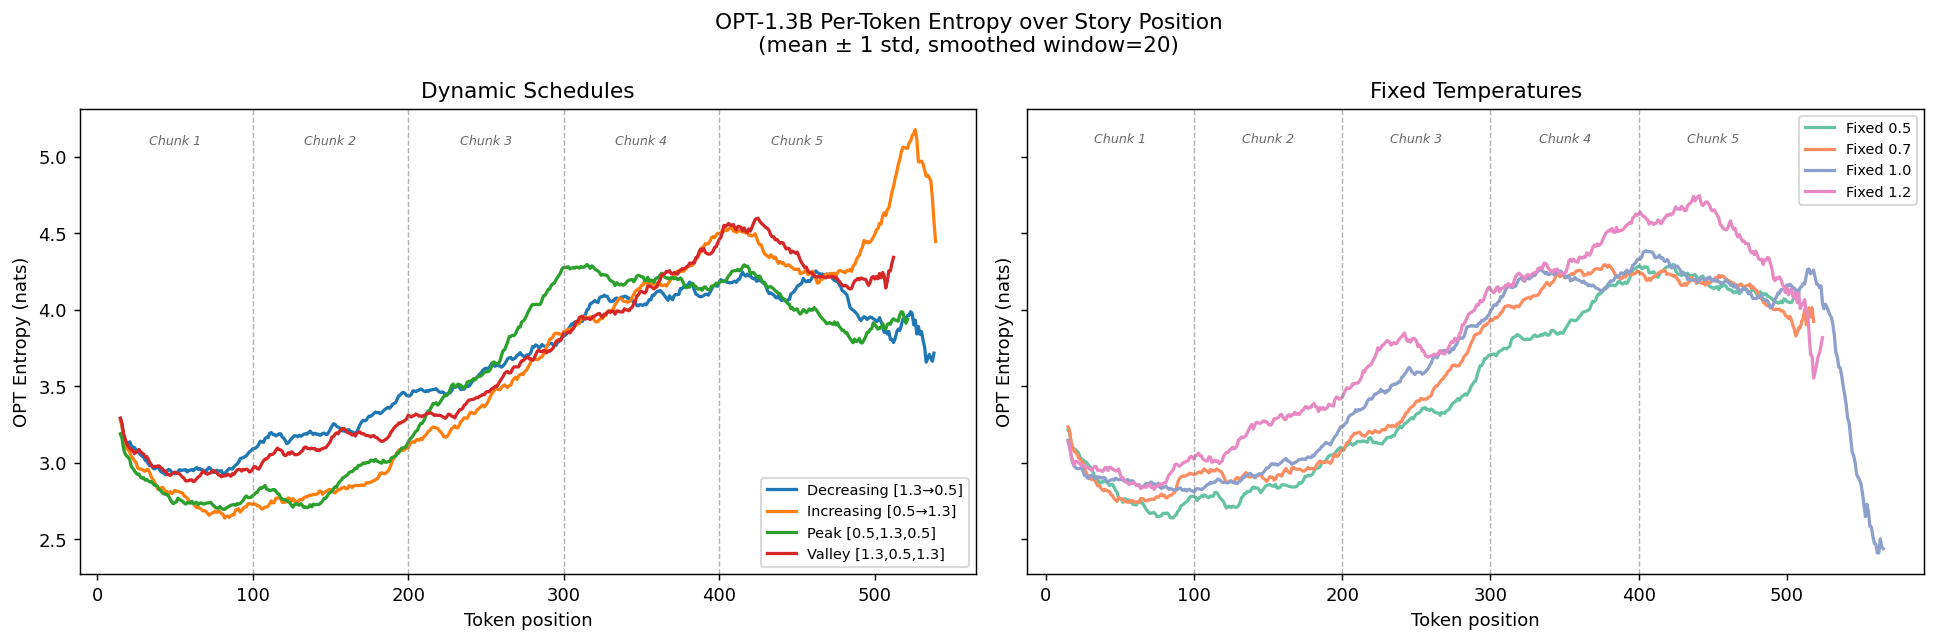

In [23]:
# ── Plot OPT entropy per token (2 panels: dynamic vs fixed) ─────────────────
SMOOTH_W_OPT = 30

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
fig.suptitle("OPT-1.3B Per-Token Entropy over Story Position\n"
             "(mean ± 1 std, smoothed window=20)", fontsize=12)

def plot_opt_entropy_panel(ax, scheds, colors, title):
    for sched, color in zip(scheds, colors):
        if sched not in opt_entropy_arrays:
            continue
        arr = opt_entropy_arrays[sched]
        if np.all(np.isnan(arr)):
            ax.text(0.5, 0.5, 'No valid data\n(re-run scoring)',
                    transform=ax.transAxes, ha='center', va='center',
                    fontsize=10, color='grey')
            break
        mean = np.nanmean(arr, axis=0)
        std  = np.nanstd(arr,  axis=0)
        xs   = np.arange(len(mean))
        ms   = smooth(mean, SMOOTH_W_OPT)
        ss   = smooth(std,  SMOOTH_W_OPT)
        pad  = SMOOTH_W_OPT // 2
        label = LABELS[sched].replace('\n', ' ')
        ax.plot(xs[pad:-pad], ms[pad:-pad], label=label, color=color, linewidth=1.8)
        # ax.fill_between(xs[pad:-pad], ms[pad:-pad] - ss[pad:-pad],
        #                 ms[pad:-pad] + ss[pad:-pad], alpha=0.15, color=color)
    for b in chunk_bounds[1:-1]:
        ax.axvline(b, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
    for j, (start, end) in enumerate(zip(chunk_bounds[:-1], chunk_bounds[1:])):
        ax.text((start + end) / 2, ax.get_ylim()[1] * 0.97,
                f'Chunk {j+1}', ha='center', va='top', fontsize=7, color='dimgrey', style='italic')
    ax.set_xlabel('Token position')
    ax.set_ylabel('OPT Entropy (nats)')
    ax.set_title(title)
    ax.legend(fontsize=8)

plot_opt_entropy_panel(axes[0], DYNAMIC_SCHEDULES, DYNAMIC_COLORS, 'Dynamic Schedules')
plot_opt_entropy_panel(axes[1], FIXED_SCHEDULES,   FIXED_COLORS,   'Fixed Temperatures')

plt.tight_layout()
plt.savefig(os.path.join('..', 'results_with_500', 'plots', 'opt_entropy_per_token.png'), dpi=150)
plt.show()

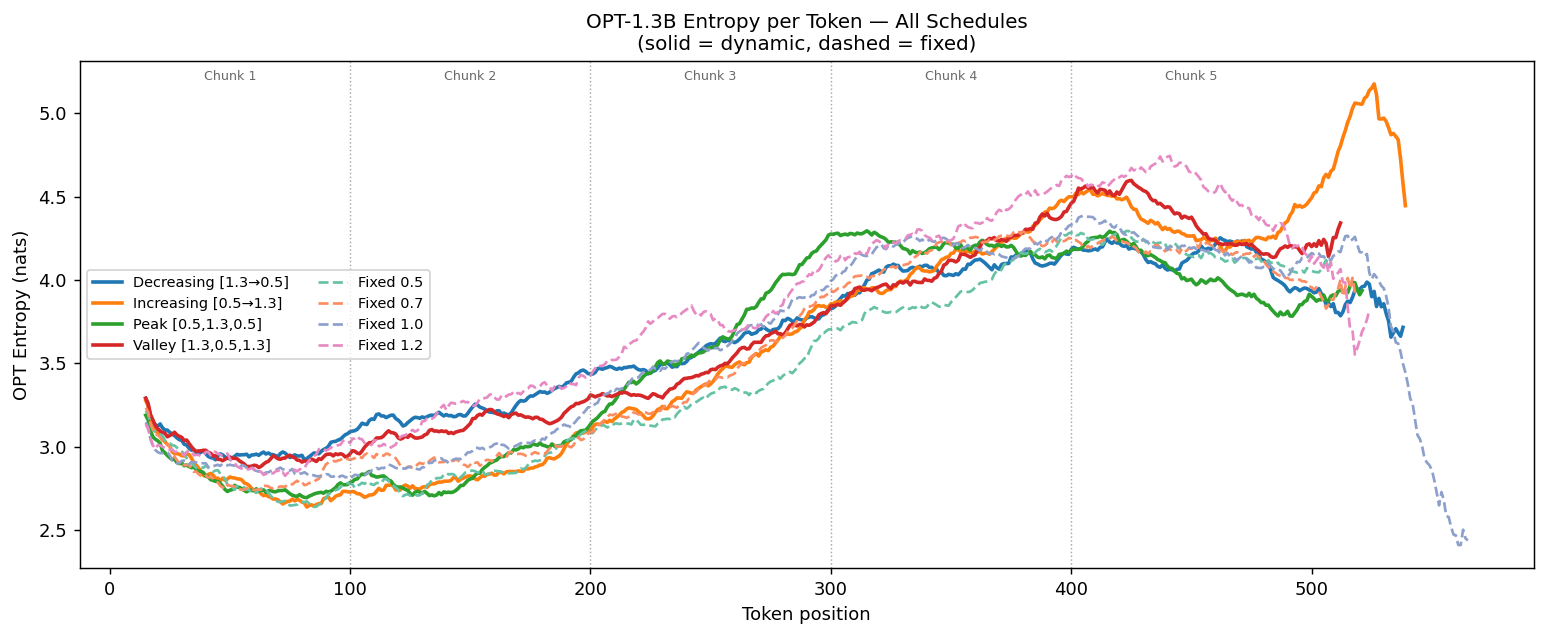

In [24]:
# ── Overlay: OPT entropy, all schedules ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
ax.set_title('OPT-1.3B Entropy per Token — All Schedules\n'
             '(solid = dynamic, dashed = fixed)', fontsize=11)

any_data = False
for i, sched in enumerate(DYNAMIC_SCHEDULES):
    if sched not in opt_entropy_arrays:
        continue
    arr = opt_entropy_arrays[sched]
    if np.all(np.isnan(arr)):
        continue
    any_data = True
    mean = np.nanmean(arr, axis=0)
    ms   = smooth(mean, SMOOTH_W_OPT)
    pad  = SMOOTH_W_OPT // 2
    xs   = np.arange(len(ms))
    ax.plot(xs[pad:-pad], ms[pad:-pad],
            label=LABELS[sched].replace('\n', ' '),
            color=DYNAMIC_COLORS[i], linewidth=2.0, linestyle='-')

for i, sched in enumerate(FIXED_SCHEDULES):
    if sched not in opt_entropy_arrays:
        continue
    arr = opt_entropy_arrays[sched]
    if np.all(np.isnan(arr)):
        continue
    any_data = True
    mean = np.nanmean(arr, axis=0)
    ms   = smooth(mean, SMOOTH_W_OPT)
    pad  = SMOOTH_W_OPT // 2
    xs   = np.arange(len(ms))
    ax.plot(xs[pad:-pad], ms[pad:-pad],
            label=LABELS[sched],
            color=FIXED_COLORS[i], linewidth=1.5, linestyle='--')

if not any_data:
    ax.text(0.5, 0.5, 'No valid opt_token_entropies found.\nRe-run notebook 06 scoring '
            'after the float16 softmax fix.',
            transform=ax.transAxes, ha='center', va='center', fontsize=11, color='grey')
else:
    for b in chunk_bounds[1:-1]:
        ax.axvline(b, color='grey', linestyle=':', linewidth=0.8, alpha=0.7)
    for j, (start, end) in enumerate(zip(chunk_bounds[:-1], chunk_bounds[1:])):
        ax.text((start + end) / 2, ax.get_ylim()[1] * 0.99,
                f'Chunk {j+1}', ha='center', va='top', fontsize=7, color='dimgrey')
    ax.legend(ncol=2, fontsize=8)

ax.set_xlabel('Token position')
ax.set_ylabel('OPT Entropy (nats)')
plt.tight_layout()
plt.savefig(os.path.join('..', 'results_with_500', 'plots', 'opt_entropy_per_token_overlay.png'), dpi=150)
plt.show()

## Plot 2 — OPT Coherence per Schedule
Bar chart (mean ± std) + box plot showing distribution of per-story `coherence_opt` scores.

In [25]:
# ── Collect coherence values ───────────────────────────────────────────────────
coherence_by_sched = {}
for sched, stories in data.items():
    vals = [s["coherence_opt"] for s in stories if not math.isnan(s["coherence_opt"])]
    coherence_by_sched[sched] = vals
    print(f"{sched:15s}: n={len(vals):3d} | mean={np.mean(vals):.4f} | std={np.std(vals):.4f}")

decreasing     : n= 50 | mean=-4.3660 | std=0.2580
increasing     : n= 50 | mean=-4.3584 | std=0.2060
peak           : n= 50 | mean=-4.3070 | std=0.2467
valley         : n= 50 | mean=-4.4627 | std=0.2267
fixed_0.5      : n= 50 | mean=-4.0826 | std=0.2197
fixed_0.7      : n= 50 | mean=-4.1507 | std=0.2415
fixed_1.0      : n= 50 | mean=-4.3883 | std=0.2353
fixed_1.2      : n= 29 | mean=-4.5303 | std=0.2296


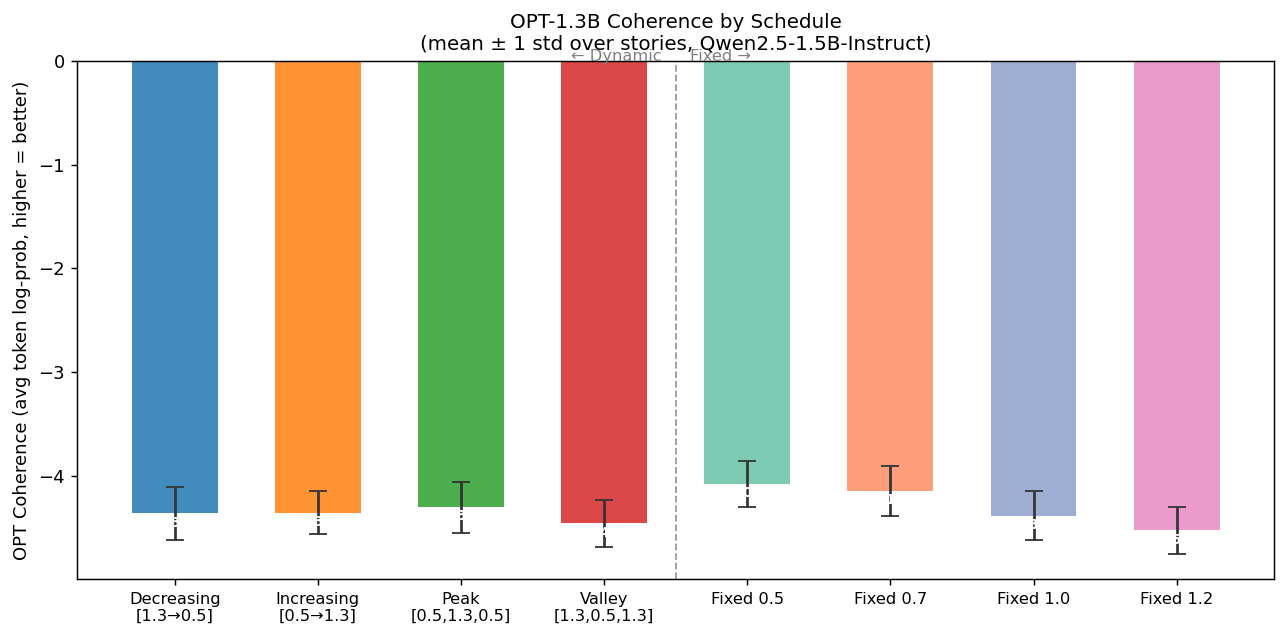

In [26]:
# ── Bar chart: mean ± std, grouped dynamic / fixed ────────────────────────────
dyn_scheds_avail   = [s for s in DYNAMIC_SCHEDULES if s in coherence_by_sched]
fixed_scheds_avail = [s for s in FIXED_SCHEDULES   if s in coherence_by_sched]

ordered = dyn_scheds_avail + fixed_scheds_avail
colors  = [DYNAMIC_COLORS[DYNAMIC_SCHEDULES.index(s)] for s in dyn_scheds_avail] + \
          [FIXED_COLORS[FIXED_SCHEDULES.index(s)]   for s in fixed_scheds_avail]
means   = [np.mean(coherence_by_sched[s]) for s in ordered]
stds    = [np.std( coherence_by_sched[s]) for s in ordered]
xlabels = [LABELS[s].replace("\n", "\n") for s in ordered]

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(ordered))
bars = ax.bar(x, means, yerr=stds, capsize=5, color=colors, alpha=0.85, width=0.6, ecolor="#333")

# Separator between dynamic and fixed
sep = len(dyn_scheds_avail) - 0.5
ax.axvline(sep, color="black", linewidth=1, linestyle="--", alpha=0.4)
ax.text(sep - 0.1, ax.get_ylim()[1] * 1.002, "← Dynamic", ha="right", fontsize=9, color="grey")
ax.text(sep + 0.1, ax.get_ylim()[1] * 1.002, "Fixed →",  ha="left",  fontsize=9, color="grey")

ax.set_xticks(x)
ax.set_xticklabels(xlabels, fontsize=9)
ax.set_ylabel("OPT Coherence (avg token log-prob, higher = better)", fontsize=10)
ax.set_title("OPT-1.3B Coherence by Schedule\n(mean ± 1 std over stories, Qwen2.5-1.5B-Instruct)", fontsize=11)

# Annotate bars with mean value
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, m - 0.02, f"{m:.3f}",
            ha="center", va="top", fontsize=8, color="white", fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join("..", "results_with_500", "plots", "opt_coherence_bar.png"), dpi=150)
plt.show()

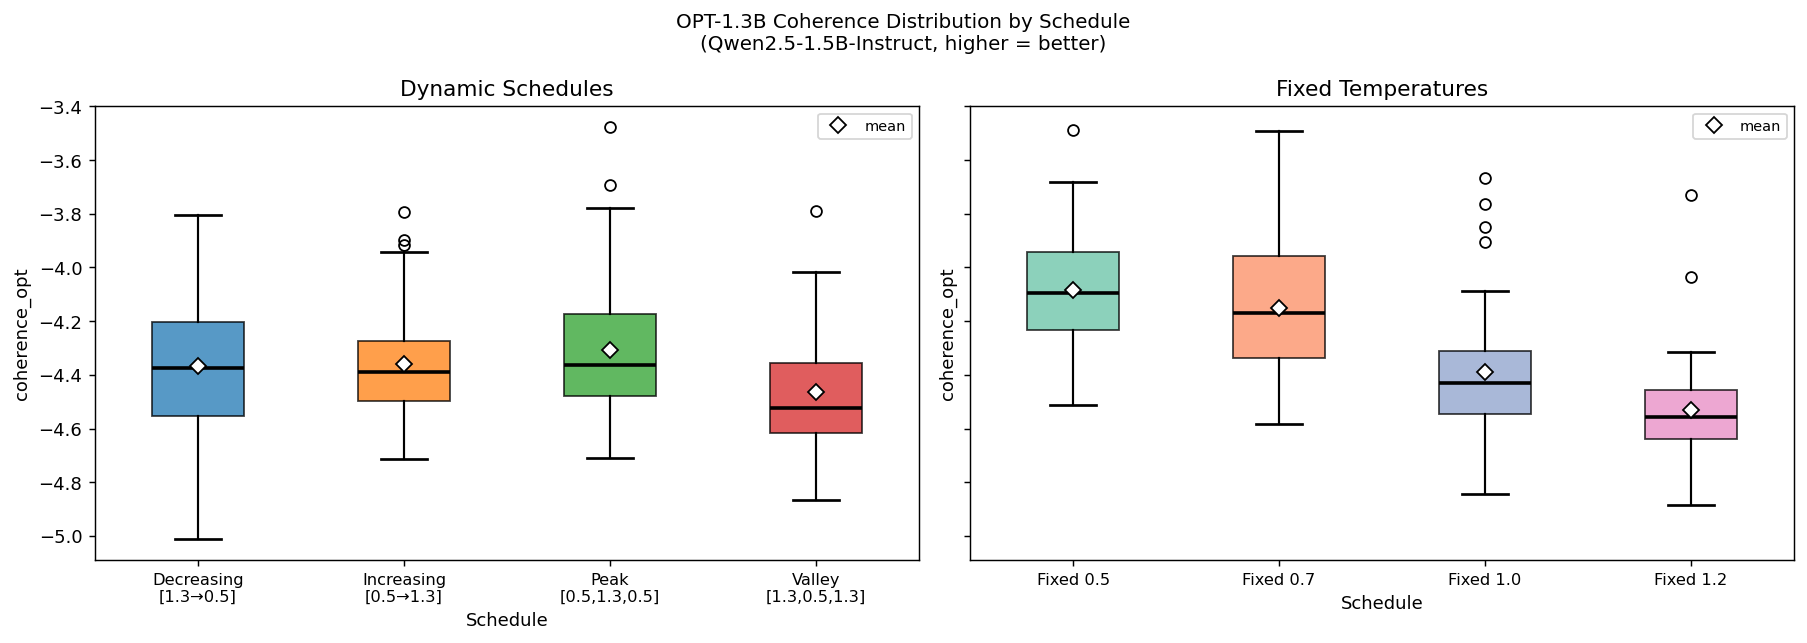

In [27]:
# ── Box plot: full distribution ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
fig.suptitle("OPT-1.3B Coherence Distribution by Schedule\n(Qwen2.5-1.5B-Instruct, higher = better)", fontsize=11)

def boxplot_panel(ax, scheds, colors, title):
    vals_list = [coherence_by_sched[s] for s in scheds if s in coherence_by_sched]
    scheds_av = [s for s in scheds if s in coherence_by_sched]
    if not vals_list:
        return
    bp = ax.boxplot(vals_list, patch_artist=True, notch=False,
                    medianprops=dict(color="black", linewidth=2),
                    whiskerprops=dict(linewidth=1.2),
                    capprops=dict(linewidth=1.5))
    for patch, color in zip(bp["boxes"], colors[:len(scheds_av)]):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    ax.set_xticks(range(1, len(scheds_av) + 1))
    ax.set_xticklabels([LABELS[s] for s in scheds_av], fontsize=9)
    ax.set_xlabel("Schedule")
    ax.set_ylabel("coherence_opt")
    ax.set_title(title)
    # Overlay mean dots
    for j, sched in enumerate(scheds_av, start=1):
        m = np.mean(coherence_by_sched[sched])
        ax.plot(j, m, marker="D", color="white", markersize=6,
                markeredgecolor="black", markeredgewidth=1, zorder=5, label="mean" if j == 1 else "")
    if scheds_av:
        ax.legend(fontsize=8)

boxplot_panel(axes[0], DYNAMIC_SCHEDULES, DYNAMIC_COLORS, "Dynamic Schedules")
boxplot_panel(axes[1], FIXED_SCHEDULES,   FIXED_COLORS,   "Fixed Temperatures")

plt.tight_layout()
plt.savefig(os.path.join("..", "results_with_500", "plots", "opt_coherence_boxplot.png"), dpi=150)
plt.show()

/var/folders/6r/xnbdm8fs39j_xss3_ly98q680000gn/T/ipykernel_15962/3081598673.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8)


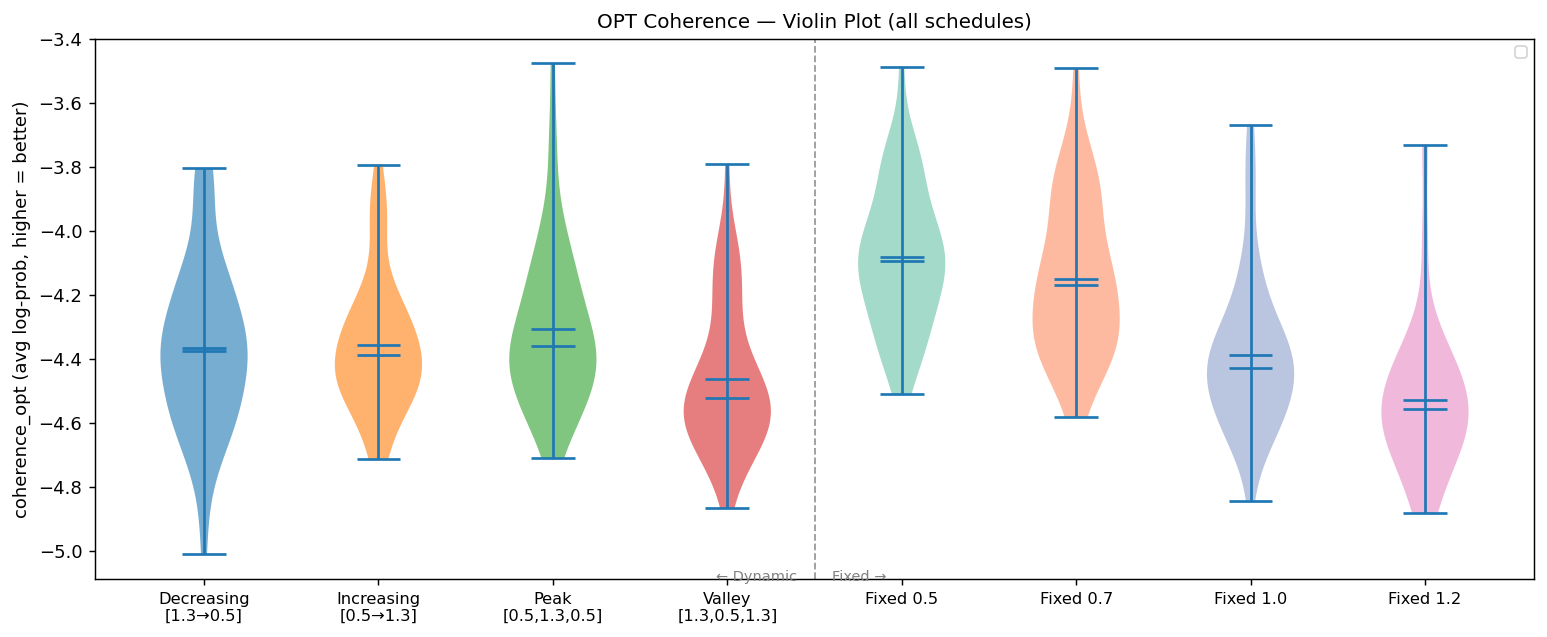

In [28]:
# ── Combined: violin plot (all schedules, side by side) ───────────────────────
ordered_all = dyn_scheds_avail + fixed_scheds_avail
vals_all    = [coherence_by_sched[s] for s in ordered_all]
colors_all  = [DYNAMIC_COLORS[DYNAMIC_SCHEDULES.index(s)] for s in dyn_scheds_avail] + \
              [FIXED_COLORS[FIXED_SCHEDULES.index(s)]   for s in fixed_scheds_avail]

fig, ax = plt.subplots(figsize=(12, 5))
ax.set_title("OPT Coherence — Violin Plot (all schedules)", fontsize=11)

parts = ax.violinplot(vals_all, positions=range(len(ordered_all)),
                      showmeans=True, showmedians=True, showextrema=True)

for pc, color in zip(parts["bodies"], colors_all):
    pc.set_facecolor(color)
    pc.set_alpha(0.6)

for component in ["cmeans", "cmedians", "cbars", "cmaxes", "cmins"]:
    if component in parts:
        parts[component].set_linewidth(1.5)

ax.set_xticks(range(len(ordered_all)))
ax.set_xticklabels([LABELS[s].replace("\n", "\n") for s in ordered_all], fontsize=9)
ax.axvline(len(dyn_scheds_avail) - 0.5, color="black", linewidth=1, linestyle="--", alpha=0.4)
ax.text(len(dyn_scheds_avail) - 0.6, ax.get_ylim()[0] * 1.001, "← Dynamic",
        ha="right", fontsize=8, color="grey")
ax.text(len(dyn_scheds_avail) - 0.4, ax.get_ylim()[0] * 1.001, "Fixed →",
        ha="left",  fontsize=8, color="grey")
ax.set_ylabel("coherence_opt (avg log-prob, higher = better)")

# Legend: means vs medians
mean_line   = mpatches.Patch(color="white",  label="— mean")
median_line = mpatches.Patch(color="white", label="-- median")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join("..", "results_with_500", "plots", "opt_coherence_violin.png"), dpi=150)
plt.show()

## Plot 3 — Entropy per Chunk × Schedule
Mean entropy within each chunk per schedule — shows how the generation model's uncertainty tracks the temperature schedule.

In [29]:
# ── Mean entropy per chunk ─────────────────────────────────────────────────────
def mean_entropy_per_chunk(stories):
    n_chunks = len(stories[0]["chunk_entropies"])
    chunk_means = []
    for c in range(n_chunks):
        vals = []
        for s in stories:
            chunk = s["chunk_entropies"][c]
            # filter -0.0 sentinels
            valid = [v for v in chunk if not (v == -0.0 and math.copysign(1, v) < 0) and not math.isnan(v)]
            if valid:
                vals.extend(valid)
        chunk_means.append(np.mean(vals) if vals else np.nan)
    return chunk_means

chunk_entropy_by_sched = {sched: mean_entropy_per_chunk(stories) for sched, stories in data.items()}

print("Mean entropy per chunk:")
for sched, means in chunk_entropy_by_sched.items():
    print(f"  {sched:15s}: {[f'{m:.3f}' for m in means]}")

Mean entropy per chunk:
  decreasing     : ['1.850', '1.927', '1.794', '1.536', '1.131']
  increasing     : ['0.930', '1.356', '1.768', '2.018', '2.103']
  peak           : ['0.925', '1.639', '2.176', '1.802', '1.101']
  valley         : ['1.878', '1.689', '1.182', '1.785', '2.093']
  fixed_0.5      : ['0.934', '1.075', '1.116', '1.141', '1.085']
  fixed_0.7      : ['1.187', '1.380', '1.484', '1.473', '1.377']
  fixed_1.0      : ['1.537', '1.782', '1.904', '1.886', '1.811']
  fixed_1.2      : ['1.756', '2.032', '2.119', '2.126', '2.015']


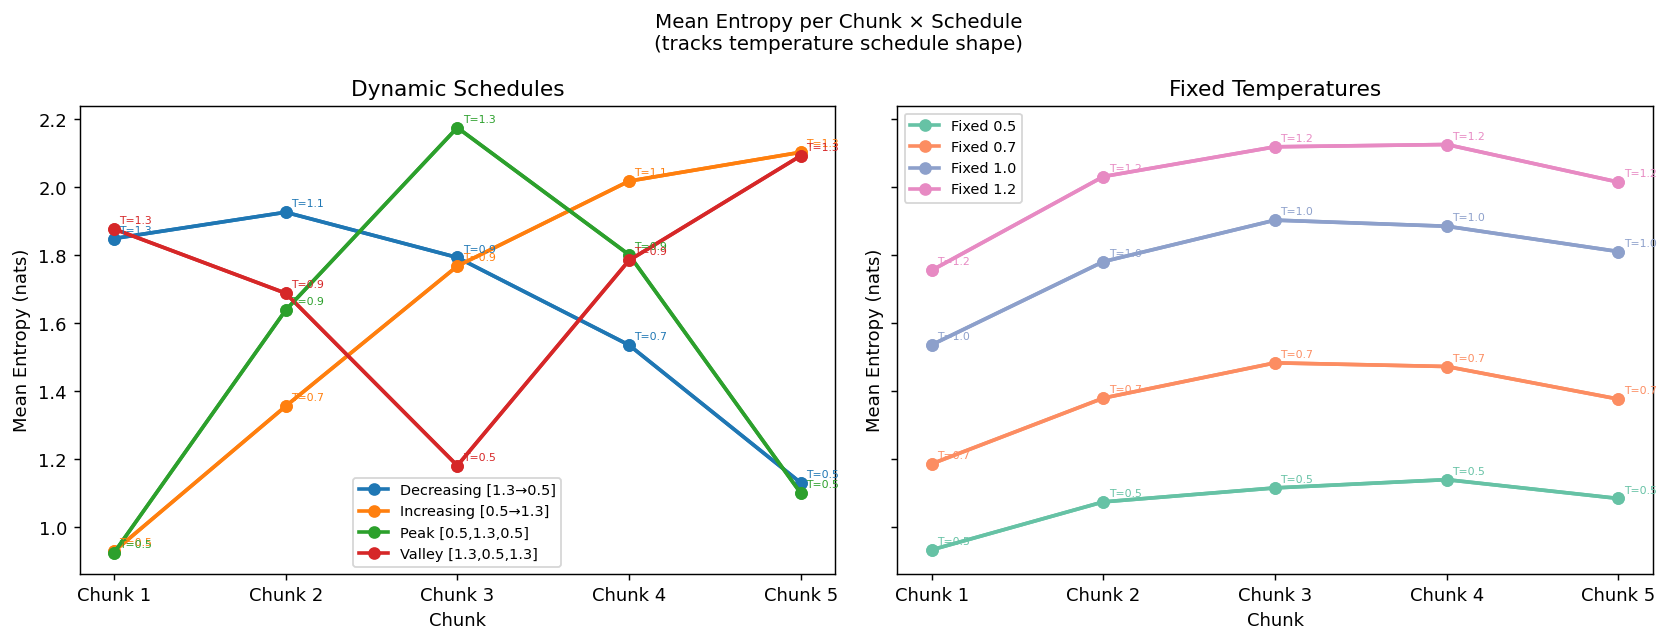

In [30]:
# ── Line plot: entropy per chunk, dynamic vs fixed ────────────────────────────
n_chunks = len(next(iter(chunk_entropy_by_sched.values())))
x_chunks = np.arange(1, n_chunks + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
fig.suptitle("Mean Entropy per Chunk × Schedule\n(tracks temperature schedule shape)", fontsize=11)

def plot_chunk_entropy(ax, scheds, colors, title):
    for sched, color in zip(scheds, colors):
        if sched not in chunk_entropy_by_sched:
            continue
        means = chunk_entropy_by_sched[sched]
        temps = data[sched][0]["temperatures"]
        label = LABELS[sched].replace("\n", " ")
        ax.plot(x_chunks, means, marker="o", linewidth=2, color=color, label=label)
        ax.plot(x_chunks, means, marker="o", linewidth=2, color=color)
        # annotate with temps
        for xc, m, t in zip(x_chunks, means, temps):
            ax.annotate(f"T={t}", xy=(xc, m), xytext=(3, 3),
                        textcoords="offset points", fontsize=6, color=color)
    ax.set_xticks(x_chunks)
    ax.set_xticklabels([f"Chunk {c}" for c in x_chunks])
    ax.set_xlabel("Chunk")
    ax.set_ylabel("Mean Entropy (nats)")
    ax.set_title(title)
    ax.legend(fontsize=8)

plot_chunk_entropy(axes[0], DYNAMIC_SCHEDULES, DYNAMIC_COLORS, "Dynamic Schedules")
plot_chunk_entropy(axes[1], FIXED_SCHEDULES,   FIXED_COLORS,   "Fixed Temperatures")

plt.tight_layout()
plt.savefig(os.path.join("..", "results_with_500", "plots", "entropy_per_chunk.png"), dpi=150)
plt.show()

## Summary Table

In [31]:
import pandas as pd

rows = []
for sched in ordered_all:
    if sched not in data:
        continue
    stories = data[sched]
    coh = coherence_by_sched[sched]
    all_ent = []
    for s in stories:
        for chunk in s["chunk_entropies"]:
            all_ent += [v for v in chunk
                        if not math.isnan(v) and not (v == -0.0 and math.copysign(1, v) < 0)]
    rows.append({
        "Schedule":        sched,
        "Type":            "dynamic" if sched in DYNAMIC_SCHEDULES else "fixed",
        "N stories":       len(stories),
        "Temperatures":    str(stories[0]["temperatures"]),
        "Coherence mean":  round(np.mean(coh), 4),
        "Coherence std":   round(np.std(coh),  4),
        "Entropy mean":    round(np.mean(all_ent), 4),
        "Entropy std":     round(np.std(all_ent),  4),
    })

df = pd.DataFrame(rows).set_index("Schedule")
df

,Type,N stories,Temperatures,Coherence mean,Coherence std,Entropy mean,Entropy std
Schedule,,,,,,,
decreasing,dynamic,50,"[1.3, 1.1, 0.9, 0.7, 0.5]",-4.3660,0.2580,1.6937,0.6236
increasing,dynamic,50,"[0.5, 0.7, 0.9, 1.1, 1.3]",-4.3584,0.2060,1.6850,0.6786
peak,dynamic,50,"[0.5, 0.9, 1.3, 0.9, 0.5]",-4.3070,0.2467,1.6151,0.6883
valley,dynamic,50,"[1.3, 0.9, 0.5, 0.9, 1.3]",-4.4627,0.2267,1.7536,0.6308
fixed_0.5,fixed,50,"[0.5, 0.5, 0.5, 0.5, 0.5]",-4.0826,0.2197,1.0733,0.4976
fixed_0.7,fixed,50,"[0.7, 0.7, 0.7, 0.7, 0.7]",-4.1507,0.2415,1.3828,0.5803
fixed_1.0,fixed,50,"[1.0, 1.0, 1.0, 1.0, 1.0]",-4.3883,0.2353,1.7829,0.5969
fixed_1.2,fixed,29,"[1.2, 1.2, 1.2, 1.2, 1.2]",-4.5303,0.2296,2.0077,0.5544


## Consolidated Summary Table

Per-schedule table combining all key metrics:
- **Coherence (OPT)** — mean avg token log-prob under OPT-1.3B (higher = more coherent)
- **Avg gen length** — mean number of generated tokens per story
- **Self-BLEU ↓** — BLEU of each story against all other stories in the same schedule (lower = more diverse)
- **Avg Token Entropy** — mean generation-model (Qwen) entropy across all tokens
- **OPT Token Entropy** — mean OPT evaluator entropy across all tokens

Dark green = best in column, light green = 2nd best.

In [37]:
import pandas as pd
import math
import numpy as np
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

smoother = SmoothingFunction().method1

# ── Helpers ──────────────────────────────────────────────────────────────────

def avg_gen_length(stories):
    """Mean number of generated tokens per story (from opt_token_entropies length)."""
    lengths = [len(s.get("opt_token_entropies", [])) for s in stories]
    return float(np.mean(lengths))

def compute_self_bleu(stories, max_stories=50):
    """Standard self-BLEU: for each story, BLEU against all other stories as references."""
    texts = [s["story"] for s in stories[:max_stories]]
    tokenized = [t.split() for t in texts]
    scores = []
    for i, hyp in enumerate(tokenized):
        refs = [r for j, r in enumerate(tokenized) if j != i]
        score = sentence_bleu(refs, hyp, smoothing_function=smoother)
        scores.append(score)
    return float(np.mean(scores))

def avg_token_entropy(stories):
    """Mean generation-model entropy (chunk_entropies) across all tokens."""
    vals = []
    for s in stories:
        for chunk in s["chunk_entropies"]:
            for v in chunk:
                if not math.isnan(v) and not (v == -0.0 and math.copysign(1, v) < 0):
                    vals.append(v)
    return float(np.mean(vals)) if vals else float("nan")

def avg_opt_token_entropy(sched):
    """Mean OPT evaluator entropy across all tokens (from opt_entropy_arrays)."""
    arr = opt_entropy_arrays.get(sched)
    if arr is None:
        return float("nan")
    return float(np.nanmean(arr))

# ── Compute metrics per schedule ──────────────────────────────────────────────

print("Computing self-BLEU (may take ~30s)...")
rows = []
for sched in (DYNAMIC_SCHEDULES + FIXED_SCHEDULES):
    if sched not in data:
        continue
    stories = data[sched]
    coh_vals = [s["coherence_opt"] for s in stories if not math.isnan(s["coherence_opt"])]

    row = {
        "Schedule":             LABELS[sched].replace("\n", " "),
        "Type":                 "dynamic" if sched in DYNAMIC_SCHEDULES else "fixed",
        "Temperatures":         str(stories[0]["temperatures"]),
        "N":                    len(stories),
        "Coherence (OPT)":      round(np.mean(coh_vals), 4),
        "Avg Gen Length":       round(avg_gen_length(stories), 1),
        "Self-BLEU ↓":          round(compute_self_bleu(stories), 4),
        "Avg Token Entropy":    round(avg_token_entropy(stories), 4),
        "OPT Token Entropy":    round(avg_opt_token_entropy(sched), 4),
    }
    rows.append(row)
    print(f"  {sched:15s}: coherence={row['Coherence (OPT)']:.4f}  "
          f"gen_len={row['Avg Gen Length']:.1f}  "
          f"self_bleu={row['Self-BLEU ↓']:.4f}  "
          f"gen_entropy={row['Avg Token Entropy']:.4f}  "
          f"opt_entropy={row['OPT Token Entropy']:.4f}")

summary_df = pd.DataFrame(rows).set_index("Schedule")
print("\nDone.")

Computing self-BLEU (may take ~30s)...
  decreasing     : coherence=-4.3660  gen_len=495.4  self_bleu=0.0301  gen_entropy=1.6937  opt_entropy=3.6079
  increasing     : coherence=-4.3584  gen_len=491.8  self_bleu=0.0457  gen_entropy=1.6850  opt_entropy=3.5213
  peak           : coherence=-4.3070  gen_len=490.2  self_bleu=0.0439  gen_entropy=1.6151  opt_entropy=3.5217
  valley         : coherence=-4.4627  gen_len=484.3  self_bleu=0.0317  gen_entropy=1.7536  opt_entropy=3.6039
  fixed_0.5      : coherence=-4.0826  gen_len=485.5  self_bleu=0.0604  gen_entropy=1.0733  opt_entropy=3.4138
  fixed_0.7      : coherence=-4.1507  gen_len=488.7  self_bleu=0.0474  gen_entropy=1.3828  opt_entropy=3.5060
  fixed_1.0      : coherence=-4.3883  gen_len=493.4  self_bleu=0.0276  gen_entropy=1.7829  opt_entropy=3.5732
  fixed_1.2      : coherence=-4.5303  gen_len=482.9  self_bleu=0.0186  gen_entropy=2.0077  opt_entropy=3.7339

Done.


In [38]:
import pandas as pd

metric_cols = ["Coherence (OPT)", "Avg Gen Length", "Self-BLEU ↓", "Avg Token Entropy", "OPT Token Entropy"]

# Best direction per metric
best_high = {"Coherence (OPT)", "Avg Gen Length", "Avg Token Entropy", "OPT Token Entropy"}
best_low  = {"Self-BLEU ↓"}

HIGHLIGHT = "background-color: #1a7a3c; color: white; font-weight: bold"
RUNNER_UP  = "background-color: #6cbf85; color: black; font-weight: bold"

def rank_column(s):
    col = s.name
    if col not in metric_cols:
        return [""] * len(s)
    numeric = pd.to_numeric(s, errors="coerce")
    ranked = numeric.rank(ascending=(col in best_low))
    styles = []
    for r in ranked:
        if r == 1:
            styles.append(HIGHLIGHT)
        elif r == 2:
            styles.append(RUNNER_UP)
        else:
            styles.append("")
    return styles

display_df = summary_df[["Type", "Temperatures", "N"] + metric_cols].copy()

styled = (
    display_df.style
    .apply(rank_column, axis=0, subset=metric_cols)
    .format({
        "Coherence (OPT)":   "{:.4f}",
        "Avg Gen Length":    "{:.1f}",
        "Self-BLEU ↓":       "{:.4f}",
        "Avg Token Entropy": "{:.4f}",
        "OPT Token Entropy": "{:.4f}",
    })
    .set_caption("Per-schedule summary — dark green = best, light green = 2nd best per column")
    .set_table_styles([
        {"selector": "th",      "props": [("background-color", "#3a3a3a"), ("color", "white"), ("font-size", "11px")]},
        {"selector": "caption", "props": [("font-size", "13px"), ("font-weight", "bold"), ("padding", "6px")]},
        # horizontal rule after the 4th row (after dynamic schedules)
        {"selector": "tbody tr:nth-child(4)", "props": [("border-bottom", "3px solid #888")]},
    ])
)
styled

,Type,Temperatures,N,Coherence (OPT),Avg Gen Length,Self-BLEU ↓,Avg Token Entropy,OPT Token Entropy
Schedule,,,,,,,,
Decreasing [1.3→0.5],dynamic,"[1.3, 1.1, 0.9, 0.7, 0.5]",50,-4.3660,495.4,0.0301,1.6937,3.6079
Increasing [0.5→1.3],dynamic,"[0.5, 0.7, 0.9, 1.1, 1.3]",50,-4.3584,491.8,0.0457,1.6850,3.5213
"Peak [0.5,1.3,0.5]",dynamic,"[0.5, 0.9, 1.3, 0.9, 0.5]",50,-4.3070,490.2,0.0439,1.6151,3.5217
"Valley [1.3,0.5,1.3]",dynamic,"[1.3, 0.9, 0.5, 0.9, 1.3]",50,-4.4627,484.3,0.0317,1.7536,3.6039
Fixed 0.5,fixed,"[0.5, 0.5, 0.5, 0.5, 0.5]",50,-4.0826,485.5,0.0604,1.0733,3.4138
Fixed 0.7,fixed,"[0.7, 0.7, 0.7, 0.7, 0.7]",50,-4.1507,488.7,0.0474,1.3828,3.5060
Fixed 1.0,fixed,"[1.0, 1.0, 1.0, 1.0, 1.0]",50,-4.3883,493.4,0.0276,1.7829,3.5732
Fixed 1.2,fixed,"[1.2, 1.2, 1.2, 1.2, 1.2]",29,-4.5303,482.9,0.0186,2.0077,3.7339
